In [ ]:
#!pip install numpy geopandas rasterio shapely matplotlib --break-system-packages

In [1]:
#import required packages
import numpy as np
import geopandas as gpd
import rasterio
from shapely.geometry import LineString, Point
import matplotlib.pyplot as plt

In [2]:
#define paths
rasterPath = '../l1processedData/Rst/topoBath_046m_Oct26.tif'
sectionPath = '../l1processedData/Shp/Model/crossSectionSW3.shp'
manningPath = '../l1processedData/Shp/channelFloodplain.shp'

151.3352617867152


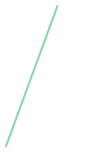

In [3]:
#create the cross section

#open the shapefile
sectionDf = gpd.read_file(sectionPath)
sectionGeom = sectionDf.geometry.iloc[0]
print(sectionGeom.length)
sectionGeom

In [4]:
manningDf = gpd.read_file(manningPath)
manningGeom = manningDf.geometry
manningGeom

0    POLYGON ((697294.26 4345869.42, 697307.475 434...
1    MULTIPOLYGON (((697729.891 4345602.865, 697685...
Name: geometry, dtype: geometry

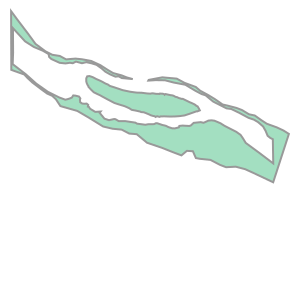

In [5]:
channelGeom = manningGeom[0]
overbankGeom = manningGeom[1]
overbankGeom

In [6]:
#sample points over the cross section
#nSamples = 150
distances = np.arange(0,sectionGeom.length) #Each one meter
points = [sectionGeom.interpolate(d) for d in distances]
coords = [(p.x, p.y) for p in points]
coords[:2]

[(697582.0285315907, 4345642.981643704),
 (697582.3714057779, 4345643.921025039)]

In [7]:
distances[:2]

array([0., 1.])

In [8]:
#extract elevations and elevArray
elevDs = rasterio.open(rasterPath) 
pointElevations = np.array([val[0] for val in elevDs.sample(coords)])
pointElevations[:2]

array([164.61377, 164.71579], dtype=float32)

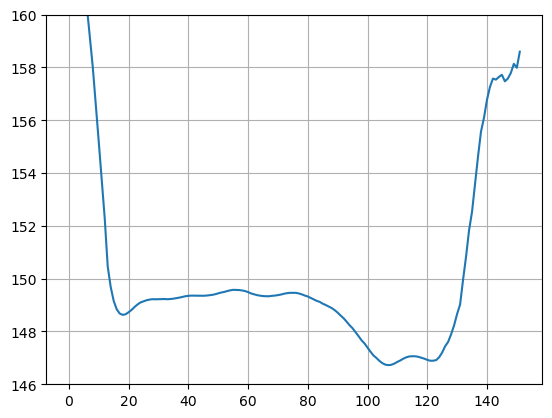

In [9]:
#plot a figure of the cross section
fig, ax = plt.subplots()
ax.plot(distances, pointElevations)
ax.set_ylim(146,160)
ax.grid()

In [ ]:
# calculate the cross section area (SA) and the wetted perimeter (P)
dx = distances[1] - distances[0]

def calculateAreaPerimeter(waterStage, areaType):
    #sectionArea = 0 #m2
    #wettedPerimeter = 0 #m.
    sectionAreaChannel = 0 #m2
    wettedPerimeterChannel = 0 #m.
    sectionAreaOverbank = 0 #m2
    wettedPerimeterOverbank = 0 #m.


    #this is a calculation over trapezoids
    for i in range(len(pointElevations)-1):
        z1 = pointElevations[i]
        z2 = pointElevations[i+1]
        
        #skip calculation if elevations are above the water stage
        if (z1 >= waterStage) and (z2 >= waterStage):
            #print('point above water table')
            continue #skips this iteration

        #water depths at both edges of the trapezoid
        d1 = max(0, waterStage - z1)
        d2 = max(0, waterStage - z2)

        #segment area as trapezoidal area
        segArea = 0.5 * (d1 + d2)*dx
        #print('The segment area is %.2f'%segArea)

        #calculate the part of the wetted perimeter
        dz = z2 - z1
        segPerimeter = np.sqrt(dx**2 + dz**2)

        #add the partial area to the total area
        if Point(coords[i]).within(channelGeom):
            sectionAreaChannel += segArea
            wettedPerimeterChannel += segPerimeter  
        if Point(coords[i]).within(overbankGeom):
            sectionAreaOverbank += segArea
            wettedPerimeterOverbank += segPerimeter  

    if areaType == 'Channel':
        return sectionAreaChannel, wettedPerimeterChannel, manningDf.iloc[0]['nManning']
    elif areaType == 'Overbank':
        return sectionAreaOverbank, wettedPerimeterOverbank, manningDf.iloc[1]['nManning']

def calculateManningFlow(sectionArea, wettedPerimeter, manningCoef, slope):
    hydraulicRadius = sectionArea / wettedPerimeter
    discharge = (1/manningCoef) * sectionArea * (hydraulicRadius**(2/3)) * np.sqrt(slope)
    return discharge


In [11]:
#calculation over all SW3 records

import pandas as pd

#open the observed data, select sheet and clip columns
dfRaw = pd.read_excel('../Csv/Observed_Head.xlsx', sheet_name='Water Level Head & Temp')
dfRaw = dfRaw.rename(columns={'Unnamed: 45':'ElevRaw'})
dfRaw = dfRaw.iloc[2:,44:46]
dfRaw = dfRaw.set_index('SW2')
dfRaw['waterStage'] = dfRaw.ElevRaw + 3.4 #fix on the datum
dfRaw.head()

/home/hatari/.local/lib/python3.12/site-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


,ElevRaw,waterStage
SW2,,
2023-01-01 00:00:00,145.262786,148.662786
2023-01-01 01:00:00,145.273004,148.673004
2023-01-01 02:00:00,145.292494,148.692494
2023-01-01 03:00:00,145.302354,148.702354
2023-01-01 04:00:00,145.318458,148.718458


In [12]:
dfJan4 = dfRaw[dfRaw.index < '2023-01-05']

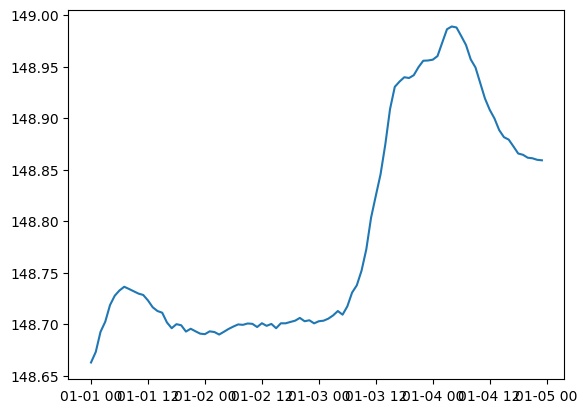

In [13]:
fig, ax = plt.subplots()
ax.plot(dfJan4.index, dfJan4.waterStage)

In [14]:
riverSlope = 0.87/623
riverSlope

0.0013964686998394864

In [15]:
dischargeList = []
i = 0
for index, row in dfRaw.iterrows():
    #meanSlope = calculateAverageSlope(elevations, row.waterStage)
    sectionAreaC, wettedPerimeterC, manningValueC = calculateAreaPerimeter(row.waterStage, 'Channel')   
    dischargeChannel = calculateManningFlow(sectionAreaC, wettedPerimeterC, manningValueC, riverSlope)

    sectionAreaO, wettedPerimeterO, manningValueO = calculateAreaPerimeter(row.waterStage, 'Overbank')   
    dischargeOverbank = calculateManningFlow(sectionAreaO, wettedPerimeterO, manningValueO, riverSlope)

    sectionArea = sectionAreaC + sectionAreaO
    wettedPerimeter = wettedPerimeterC + wettedPerimeterO   
    hydraulicRadius =  sectionArea/wettedPerimeter

    totalDischarge = dischargeChannel + dischargeOverbank

    dischargeList.append(totalDischarge)

    if row.waterStage > 149.8:
        print('The section areas is %.2f m2. The wettedPerimeter is %.2f m'%(sectionArea,wettedPerimeter))
        print('The discharge is %.2f'%totalDischarge)
        print('-------')
    i+=1

In [16]:
dfRaw['flowm3s'] = dischargeList
dfRaw.head()

,ElevRaw,waterStage,flowm3s
SW2,,,
2023-01-01 00:00:00,145.262786,148.662786,81.452585
2023-01-01 01:00:00,145.273004,148.673004,82.446497
2023-01-01 02:00:00,145.292494,148.692494,84.295075
2023-01-01 03:00:00,145.302354,148.702354,85.274388
2023-01-01 04:00:00,145.318458,148.718458,86.817943


In [20]:
dfRaw.to_csv('../l1processedData/Xls/flowMiamiRiver_s0013_nc03_no028.csv')

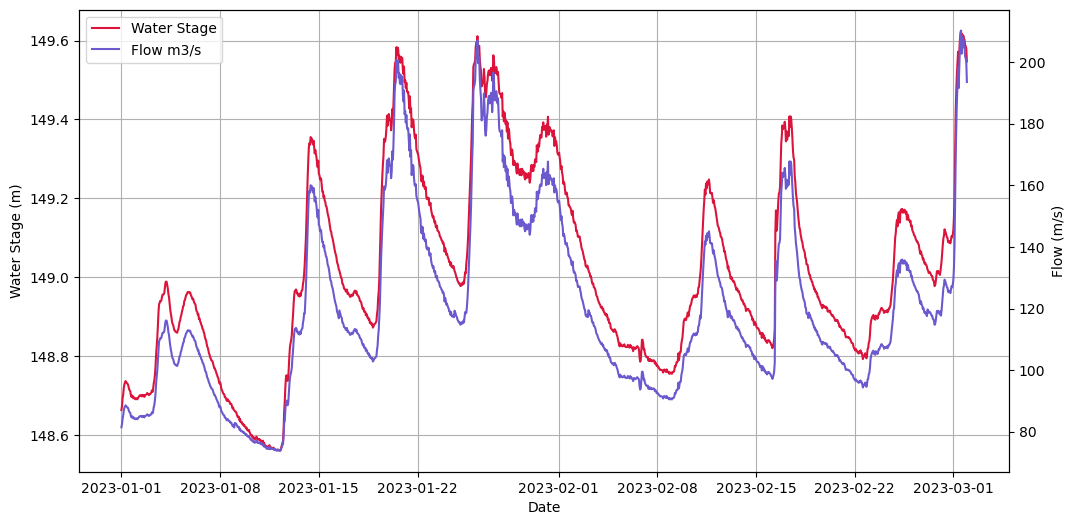

In [19]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(dfRaw.index, dfRaw.waterStage, label='Water Stage', color = 'crimson')
ax1.set_xlabel('Date')
ax1.set_ylabel('Water Stage (m)')

ax2 = ax1.twinx()
ax2.plot(dfRaw.index, dfRaw.flowm3s, label='Flow m3/s', color ='slateblue')
ax2.set_ylabel('Flow (m/s)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
#ax1.set_xlim(dfRaw.index[1080],dfRaw.index[1180])
#ax2.legend()
ax1.grid()

plt.show()